In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'


In [2]:
import os
import gc
import torch
import numpy as np
import random
import warnings
import torch.amp

# Suppress all non-critical warnings
warnings.filterwarnings('ignore')
os.environ['HF_HUB_DISABLE_IMPLICIT_TOKEN'] = '1'   # silence HuggingFace warning
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'  # reduce fragmentation

# Seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Speed settings — deterministic OFF gives ~30% faster training
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark     = True
torch.set_float32_matmul_precision('high')  # uses TF32 on Ampere GPUs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Full GPU cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# System report
total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
allocated  = torch.cuda.memory_allocated(0) / 1e9
reserved   = torch.cuda.memory_reserved(0)  / 1e9

import psutil
ram_free = psutil.virtual_memory().available / 1e9
ram_total = psutil.virtual_memory().total / 1e9

import shutil
_, _, disk_free = shutil.disk_usage('D:/')
disk_free_gb = disk_free / 1e9

print('=' * 58)
print('DEEPFAKE DETECTION v3 — SYSTEM CHECK')
print('=' * 58)
print(f'  PyTorch    : {torch.__version__}')
print(f'  Device     : {device}')
print(f'  GPU        : {torch.cuda.get_device_name(0)}')
print(f'  VRAM total : {total_vram:.2f} GB')
print(f'  VRAM used  : {allocated:.3f} GB  (must be <0.1 before training)')
print(f'  RAM free   : {ram_free:.1f} / {ram_total:.1f} GB  (need >6 GB free)')
print(f'  Disk D: free: {disk_free_gb:.1f} GB  (need >5 GB for checkpoints)')
print(f'  cudnn bench: {torch.backends.cudnn.benchmark}')
print('=' * 58)

# Gate checks
ok = True
if allocated > 0.3:
    print('  FAIL: VRAM not clean — do Kernel Restart')
    ok = False
if ram_free < 6.0:
    print(f'  WARN: Only {ram_free:.1f} GB RAM free — training may be slow')
if disk_free_gb < 5.0:
    print(f'  WARN: Only {disk_free_gb:.1f} GB disk free — checkpoint saves may fail')
if ok:
    print('\n  All checks passed — safe to proceed')

DEEPFAKE DETECTION v3 — SYSTEM CHECK
  PyTorch    : 2.5.1+cu121
  Device     : cuda
  GPU        : NVIDIA GeForce RTX 2050
  VRAM total : 4.29 GB
  VRAM used  : 0.000 GB  (must be <0.1 before training)
  RAM free   : 5.8 / 16.3 GB  (need >6 GB free)
  Disk D: free: 57.6 GB  (need >5 GB for checkpoints)
  cudnn bench: True
  WARN: Only 5.8 GB RAM free — training may be slow

  All checks passed — safe to proceed


In [3]:
# CONFIGURATION
# Key fixes vs v2:

TRAIN_CONFIG = {
    'processed_dir'  : 'D:/deepfake_project/data/processed',
    'checkpoint_dir' : 'D:/deepfake_project/models/checkpoints',
    'log_dir'        : 'D:/deepfake_project/logs',

    'model_name'   : 'efficientnet_b4',
    'pretrained'   : True,
    'dropout1'     : 0.4,
    'dropout2'     : 0.2,
    'hidden_units' : 512,

    'batch_size'       : 8,
    'grad_accum_steps' : 2,    # effective batch = 16
    'num_epochs'       : 40,
    'patience'         : 10,
    'min_delta'        : 0.001,
    'num_workers'      : 0,    # must be 0 on Windows Jupyter

    # Phase 1 — backbone frozen, train head only
    'phase1_epochs'      : 5,      # 5 epochs gives a stronger head before unfreezing
    'lr_head_phase1'     : 1e-3,

    # Phase 2 — full fine-tune with SAFE learning rates
    'lr_backbone_phase2' : 1e-5,   
    'lr_head_phase2'     : 5e-5,  
    'weight_decay'       : 1e-4,
    'warmup_epochs'      : 5,      
    'warmup_start_factor': 0.05,   
    'eta_min'            : 1e-7,  

    'focal_gamma'    : 2.0,
    'label_smoothing': 0.05,
    'use_amp'        : True,

    'mean'       : [0.485, 0.456, 0.406],
    'std'        : [0.229, 0.224, 0.225],
    'image_size' : 380,
}

os.makedirs(TRAIN_CONFIG['checkpoint_dir'], exist_ok=True)
os.makedirs(TRAIN_CONFIG['log_dir'],        exist_ok=True)

print('TRAIN_CONFIG ready')
print(f'  Phase 1 : {TRAIN_CONFIG["phase1_epochs"]} epochs, head only, LR={TRAIN_CONFIG["lr_head_phase1"]:.0e}')
print(f'  Phase 2 : {TRAIN_CONFIG["num_epochs"] - TRAIN_CONFIG["phase1_epochs"]} epochs')
print(f'  Backbone LR : {TRAIN_CONFIG["lr_backbone_phase2"]:.0e}  (reduced to prevent NaN)')
print(f'  Head LR     : {TRAIN_CONFIG["lr_head_phase2"]:.0e}')
print(f'  Warmup      : {TRAIN_CONFIG["warmup_epochs"]} epochs from {TRAIN_CONFIG["warmup_start_factor"]*100:.0f}% to 100%')
print(f'  Batch       : {TRAIN_CONFIG["batch_size"]} physical x{TRAIN_CONFIG["grad_accum_steps"]} = {TRAIN_CONFIG["batch_size"]*TRAIN_CONFIG["grad_accum_steps"]} effective')

TRAIN_CONFIG ready
  Phase 1 : 5 epochs, head only, LR=1e-03
  Phase 2 : 35 epochs
  Backbone LR : 1e-05  (reduced to prevent NaN)
  Head LR     : 5e-05
  Warmup      : 5 epochs from 5% to 100%
  Batch       : 8 physical x2 = 16 effective


In [4]:
# DATASET CLASS
import cv2
import numpy as np
import random as rnd
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
from pathlib import Path


class DeepfakeDataset(Dataset):

    def __init__(self, root_dir, split, augment=False, label_smoothing=0.0):
        self.samples         = []
        self.augment         = augment
        self.label_smoothing = label_smoothing

        # Keep on CPU — moved to GPU only during training
        self._mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self._std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        # Created once — not per image (was a bug in earlier versions)
        self._color_jitter = T.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
        )

        # real/ folder = label 0,  fake/ folder = label 1
        for label_name, label_val in [('real', 0), ('fake', 1)]:
            folder = os.path.join(root_dir, split, label_name)
            if not os.path.exists(folder):
                print(f'  Missing: {folder}')
                continue
            for f in Path(folder).glob('*.npz'):
                self.samples.append((str(f), label_val))

        if split == 'train':
            rnd.seed(42)
            rnd.shuffle(self.samples)

        r = sum(1 for _, l in self.samples if l == 0)
        f = sum(1 for _, l in self.samples if l == 1)
        print(f'  {split:5s}: {len(self.samples):,}  ({r:,} real=0 / {f:,} fake=1)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        img = np.load(fpath)['img']  # already normalized float32 (380,380,3)
        t   = torch.from_numpy(img.copy()).permute(2, 0, 1).float()

        if self.augment:
            t = self._augment(t)

        if self.label_smoothing > 0:
            soft = self.label_smoothing if label == 0 else 1.0 - self.label_smoothing
            return t, torch.tensor(soft, dtype=torch.float32)
        return t, torch.tensor(float(label), dtype=torch.float32)

    def _augment(self, t):
        if rnd.random() < 0.5:
            t = TF.hflip(t)
        if rnd.random() < 0.4:
            t = TF.rotate(t, rnd.uniform(-12, 12),
                          interpolation=TF.InterpolationMode.BILINEAR)
        if rnd.random() < 0.6:
            t = self._color_jitter(t)
        if rnd.random() < 0.3:          # reduced from 0.5 — JPEG compress is slow
            t = self._jpeg_compress(t)
        if rnd.random() < 0.3:
            t = TF.gaussian_blur(t, kernel_size=5, sigma=rnd.uniform(0.3, 1.5))
        if rnd.random() < 0.1:
            t = TF.rgb_to_grayscale(t, num_output_channels=3)
        if rnd.random() < 0.15:
            t = T.RandomErasing(p=1.0, scale=(0.01, 0.06), value=0)(t)
        return t

    def _jpeg_compress(self, t):
        img_np = ((t * self._std + self._mean)
                  .clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        q = rnd.randint(50, 95)
        _, enc = cv2.imencode('.jpg', cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR),
                              [cv2.IMWRITE_JPEG_QUALITY, q])
        dec = cv2.cvtColor(cv2.imdecode(enc, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        f = torch.from_numpy(dec.astype(np.float32) / 255.0).permute(2, 0, 1)
        return (f - self._mean) / self._std


print('DeepfakeDataset defined  |  real=0  fake=1')

DeepfakeDataset defined  |  real=0  fake=1


In [5]:
# CELL 4 — DATALOADERS

from torch.utils.data import DataLoader

processed_dir = TRAIN_CONFIG['processed_dir']
print('Loading datasets...\n')

train_ds = DeepfakeDataset(processed_dir, 'train', augment=True,
                           label_smoothing=TRAIN_CONFIG['label_smoothing'])
val_ds   = DeepfakeDataset(processed_dir, 'val',   augment=False, label_smoothing=0.0)
test_ds  = DeepfakeDataset(processed_dir, 'test',  augment=False, label_smoothing=0.0)

train_loader = DataLoader(train_ds,
    batch_size=TRAIN_CONFIG['batch_size'], shuffle=True,
    num_workers=0, pin_memory=True, persistent_workers=False, drop_last=True)
val_loader = DataLoader(val_ds,
    batch_size=TRAIN_CONFIG['batch_size']*2, shuffle=False,
    num_workers=0, pin_memory=True, persistent_workers=False)
test_loader = DataLoader(test_ds,
    batch_size=TRAIN_CONFIG['batch_size']*2, shuffle=False,
    num_workers=0, pin_memory=True, persistent_workers=False)

# Verify
sample_imgs, sample_labels = next(iter(train_loader))
print(f'\n  Batch shape : {sample_imgs.shape}  (should be [8,3,380,380])')
print(f'  Pixel range : [{sample_imgs.min():.2f}, {sample_imgs.max():.2f}]  (negative = normalized OK)')
print(f'  Labels      : {sample_labels[:6].tolist()}')
assert sample_imgs.shape[-1] == 380, 'Wrong size — delete old processed folder and re-preprocess'
assert sample_imgs.min() < 0, 'Images not normalized'
print('\n  DataLoaders ready')

Loading datasets...

  train: 57,451  (28,091 real=0 / 29,360 fake=1)
  val  : 7,303  (3,633 real=0 / 3,670 fake=1)
  test : 7,308  (3,638 real=0 / 3,670 fake=1)

  Batch shape : torch.Size([8, 3, 380, 380])  (should be [8,3,380,380])
  Pixel range : [-2.11, 2.64]  (negative = normalized OK)
  Labels      : [0.05000000074505806, 0.949999988079071, 0.05000000074505806, 0.949999988079071, 0.05000000074505806, 0.949999988079071]

  DataLoaders ready


In [6]:
# CELL 5 — MODEL + FOCAL LOSS

import timm
import torch.nn as nn
import torch.nn.functional as F


class DeepfakeEfficientNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(
            cfg['model_name'], pretrained=cfg['pretrained'],
            num_classes=0, global_pool='avg'
        )
        feat = self.backbone.num_features  # 1792

        self.classifier = nn.Sequential(
            nn.Dropout(cfg['dropout1']),
            nn.Linear(feat, cfg['hidden_units']),
            nn.GELU(),
            nn.BatchNorm1d(cfg['hidden_units']),
            nn.Dropout(cfg['dropout2']),
            nn.Linear(cfg['hidden_units'], 1),
        )
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.backbone(x)).squeeze(1)

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
        print('  Backbone FROZEN')

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True
        print('  Backbone UNFROZEN')


class FocalLoss(nn.Module):
    """Down-weights easy samples, forces learning on hard borderline cases."""
    def __init__(self, gamma=2.0, alpha=0.5):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        bce   = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt    = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()


print('Building EfficientNet-B4...')
model = DeepfakeEfficientNet(TRAIN_CONFIG).to(device)

gc.collect()
torch.cuda.empty_cache()

n_params = sum(p.numel() for p in model.parameters())
vram_free = (torch.cuda.get_device_properties(0).total_memory
             - torch.cuda.memory_allocated(0)) / 1e9
print(f'  Params    : {n_params:,}')
print(f'  Features  : {model.backbone.num_features}')
print(f'  VRAM free : {vram_free:.2f} GB')

# Quick test
with torch.no_grad():
    _out = model(sample_imgs.to(device))
print(f'  Forward   : {_out.shape}  range [{_out.min():.2f}, {_out.max():.2f}]')
del _out

# Free test tensors
for _v in ['sample_imgs', 'sample_labels']:
    if _v in globals(): del globals()[_v]
torch.cuda.empty_cache()
print('Model ready')

Building EfficientNet-B4...
  Params    : 18,468,169
  Features  : 1792
  VRAM free : 4.22 GB
  Forward   : torch.Size([8])  range [-1.23, 1.60]
Model ready


In [7]:
# CELL 6 — TRAIN / VALIDATE FUNCTIONS

from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm
import gc


def train_one_epoch(model, loader, criterion, optimizer,
                    scaler, device, grad_accum_steps,
                    best_path, cfg):
    model.train()
    total_loss  = 0.0
    all_probs   = []
    all_labels  = []
    correct = total = nan_batches = 0
    nan_triggered_reload = False

    optimizer.zero_grad()
    pbar = tqdm(loader, desc='  Train', leave=False, ncols=100)

    for batch_idx, (imgs, labels) in enumerate(pbar):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=cfg['use_amp']):
            outputs = model(imgs)
            loss    = criterion(outputs, labels) / grad_accum_steps

        if torch.isnan(loss) or torch.isinf(loss) or torch.isnan(outputs).any():
            nan_batches += 1
            optimizer.zero_grad()
            # Reset scaler state
            scaler = torch.amp.GradScaler('cuda', enabled=cfg['use_amp'])
            del imgs, labels, outputs, loss
            torch.cuda.empty_cache()

            if os.path.exists(best_path) and not nan_triggered_reload:
                ckpt = torch.load(best_path, map_location=device)
                model.load_state_dict(ckpt['model_state'])
                model.train()
                del ckpt
                torch.cuda.empty_cache()
                nan_triggered_reload = True
                print(f'  NaN at batch {batch_idx} — reloaded checkpoint, continuing')
            continue

        scaler.scale(loss).backward()

        if (batch_idx + 1) % grad_accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)  # tighter clip
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        loss_val    = loss.item() * grad_accum_steps
        probs       = torch.sigmoid(outputs).detach().cpu().numpy()
        hard_labels = (labels > 0.5).float().cpu().numpy()
        preds       = (probs >= 0.5).astype(int)

        total_loss += loss_val * imgs.size(0)
        correct    += (preds == hard_labels).sum()
        total      += imgs.size(0)
        all_probs.extend(probs.tolist())
        all_labels.extend(hard_labels.tolist())

        del imgs, labels, outputs, loss
        if batch_idx % 200 == 0:
            torch.cuda.empty_cache()

        pbar.set_postfix({'loss': f'{loss_val:.4f}',
                          'vram': f'{torch.cuda.memory_allocated(0)/1e9:.1f}G',
                          'nan' : nan_batches})

    if nan_batches > 0:
        print(f'  Epoch had {nan_batches} NaN batches (checkpoint reloaded)')

    if total == 0:
        return float('nan'), 0.0, 0.5, scaler

    auc = 0.5
    try: auc = roc_auc_score(all_labels, all_probs)
    except: pass
    return total_loss / total, float(correct / total), auc, scaler


def validate(model, loader, criterion, device, cfg):
    model.eval()
    total_loss = 0.0
    all_probs  = []
    all_labels = []
    correct = total = nan_count = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='  Val  ', leave=False, ncols=100):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=cfg['use_amp']):
                outputs = model(imgs)
                loss    = criterion(outputs, labels)

            if torch.isnan(loss) or torch.isinf(loss) or torch.isnan(outputs).any():
                nan_count += 1
                del imgs, labels, outputs, loss
                continue

            probs       = torch.sigmoid(outputs).cpu().numpy()
            hard_labels = (labels > 0.5).float().cpu().numpy()

            total_loss += loss.item() * imgs.size(0)
            correct    += ((probs >= 0.5).astype(int) == hard_labels).sum()
            total      += imgs.size(0)
            all_probs.extend(probs.tolist())
            all_labels.extend(hard_labels.tolist())
            del imgs, labels, outputs, loss

    if nan_count > 0:
        print(f'  Val: {nan_count}/{nan_count+total//8} batches had NaN (weights may be corrupted)')

    if total == 0:
        return float('nan'), 0.0, 0.5

    auc = 0.5
    try: auc = roc_auc_score(all_labels, all_probs)
    except: pass
    return total_loss / total, float(correct / total), auc


print('train_one_epoch() and validate() ready')

train_one_epoch() and validate() ready


In [8]:
# COMBINED TRAINING LOOP (Phase 1 + Phase 2)
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import json, time, gc

history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [],
    'val_loss':   [], 'val_acc':   [], 'val_auc':   [],
    'lr': [], 'phase': [],
}

best_val_auc   = 0.0
best_epoch     = 0
patience_count = 0
GRAD_ACCUM     = TRAIN_CONFIG['grad_accum_steps']
P1_EPOCHS      = TRAIN_CONFIG['phase1_epochs']

best_path = os.path.join(TRAIN_CONFIG['checkpoint_dir'], 'best_model_v3.pth')
last_path = os.path.join(TRAIN_CONFIG['checkpoint_dir'], 'last_model_v3.pth')

criterion = FocalLoss(gamma=TRAIN_CONFIG['focal_gamma'])

# Phase 1 optimizer — head only
model.freeze_backbone()
optimizer = optim.AdamW(model.classifier.parameters(),
                        lr=TRAIN_CONFIG['lr_head_phase1'],
                        weight_decay=TRAIN_CONFIG['weight_decay'])
scaler = torch.amp.GradScaler('cuda', enabled=TRAIN_CONFIG['use_amp'])

gc.collect()
torch.cuda.empty_cache()

print('=' * 72)
print('TRAINING START')
print(f'  Phase 1: epochs 1-{P1_EPOCHS} (head only)')
print(f'  Phase 2: epochs {P1_EPOCHS+1}-{TRAIN_CONFIG["num_epochs"]} (full fine-tune)')
print('=' * 72)

start_time = time.time()

for epoch in range(1, TRAIN_CONFIG['num_epochs'] + 1):

    # ── Phase transition: switch optimizer at epoch P1_EPOCHS+1 ──
    if epoch == P1_EPOCHS + 1:
        print(f'\n  Switching to Phase 2 (full fine-tune)')
        model.unfreeze_backbone()

        # Phase 2 optimizer with SAFE differential LRs
        optimizer = optim.AdamW(
            [
                {'params': model.backbone.parameters(),
                 'lr': TRAIN_CONFIG['lr_backbone_phase2']},   # 1e-5 (safe)
                {'params': model.classifier.parameters(),
                 'lr': TRAIN_CONFIG['lr_head_phase2']},       # 5e-5
            ],
            weight_decay=TRAIN_CONFIG['weight_decay']
        )

        p2_total = TRAIN_CONFIG['num_epochs'] - P1_EPOCHS
        warmup_ep = TRAIN_CONFIG['warmup_epochs']

        warmup_sched = LinearLR(
            optimizer,
            start_factor = TRAIN_CONFIG['warmup_start_factor'],  # 0.05
            end_factor   = 1.0,
            total_iters  = warmup_ep
        )
        cosine_sched = CosineAnnealingLR(
            optimizer,
            T_max   = max(1, p2_total - warmup_ep),
            eta_min = TRAIN_CONFIG['eta_min']
        )
        scheduler_p2 = SequentialLR(
            optimizer,
            schedulers=[warmup_sched, cosine_sched],
            milestones=[warmup_ep]
        )

        # Fresh scaler for Phase 2
        scaler = torch.amp.GradScaler('cuda', enabled=TRAIN_CONFIG['use_amp'])
        patience_count = 0  # reset patience for Phase 2

        all_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Phase 2 trainable params: {all_p:,}')
        print(f'  Backbone LR: {TRAIN_CONFIG["lr_backbone_phase2"]:.0e}')
        print(f'  Head LR    : {TRAIN_CONFIG["lr_head_phase2"]:.0e}')
        print(f'  Warmup     : {warmup_ep} epochs from {TRAIN_CONFIG["warmup_start_factor"]*100:.0f}%')
        print()

    t0 = time.time()

    # ── Train ──
    train_loss, train_acc, train_auc, scaler = train_one_epoch(
        model, train_loader, criterion, optimizer,
        scaler, device, GRAD_ACCUM, best_path, TRAIN_CONFIG
    )

    gc.collect()
    torch.cuda.empty_cache()

    # ── Validate ──
    val_loss, val_acc, val_auc = validate(
        model, val_loader, criterion, device, TRAIN_CONFIG
    )

    gc.collect()
    torch.cuda.empty_cache()

    # ── Scheduler step (Phase 2 only) ──
    if epoch > P1_EPOCHS:
        scheduler_p2.step()
        current_lr = optimizer.param_groups[1]['lr']
    else:
        current_lr = optimizer.param_groups[0]['lr']

    # ── History ──
    history['train_loss'].append(round(float(train_loss) if train_loss == train_loss else 0, 6))
    history['train_acc'].append(round(train_acc, 6))
    history['train_auc'].append(round(train_auc, 6))
    history['val_loss'].append(round(float(val_loss) if val_loss == val_loss else 0, 6))
    history['val_acc'].append(round(val_acc, 6))
    history['val_auc'].append(round(val_auc, 6))
    history['lr'].append(round(current_lr, 10))
    history['phase'].append(1 if epoch <= P1_EPOCHS else 2)

    # ── Save best ──
    saved = ''
    val_ok = val_auc == val_auc  # not NaN
    if val_ok and val_auc > best_val_auc + TRAIN_CONFIG['min_delta']:
        best_val_auc   = val_auc
        best_epoch     = epoch
        patience_count = 0
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'val_auc'     : val_auc,
            'val_acc'     : val_acc,
            'config'      : TRAIN_CONFIG,
        }, best_path)
        saved = '  BEST'
    elif val_ok:
        patience_count += 1
    # If val_auc is NaN, do NOT increment patience (broken measurement)

    # ── Save last ──
    torch.save({
        'epoch'      : epoch,
        'model_state': model.state_dict(),
        'history'    : history,
    }, last_path)

    # ── Print ──
    phase_tag  = 'Ph1' if epoch <= P1_EPOCHS else 'Ph2'
    epoch_secs = time.time() - t0
    elapsed    = (time.time() - start_time) / 60
    vram_used  = torch.cuda.memory_allocated(0) / 1e9
    val_str    = f'{val_auc:.4f}' if val_ok else 'NaN(no-patience)'

    print(
        f'{phase_tag} Ep {epoch:02d}/{TRAIN_CONFIG["num_epochs"]} | '
        f'Tr Loss:{train_loss:.4f} AUC:{train_auc:.4f} Acc:{train_acc:.4f} | '
        f'Va Loss:{val_loss:.4f} AUC:{val_str} Acc:{val_acc:.4f} | '
        f'LR:{current_lr:.1e} VRAM:{vram_used:.2f}G | '
        f'{epoch_secs:.0f}s {elapsed:.0f}m{saved}'
    )

    # ── Early stopping (only counts valid val measurements) ──
    if patience_count >= TRAIN_CONFIG['patience']:
        print(f'\n  Early stopping at epoch {epoch}')
        print(f'  Best Val AUC: {best_val_auc:.4f} at epoch {best_epoch}')
        break

total_time = (time.time() - start_time) / 60
print(f'\nTraining complete')
print(f'  Best Val AUC : {best_val_auc:.4f} at epoch {best_epoch}')
print(f'  Total time   : {total_time:.1f} minutes')

with open(os.path.join(TRAIN_CONFIG['log_dir'], 'history_v3.json'), 'w') as f:
    json.dump(history, f, indent=2)
print('  History saved')

  Backbone FROZEN
TRAINING START
  Phase 1: epochs 1-5 (head only)
  Phase 2: epochs 6-40 (full fine-tune)


  Train:   0%|                                                             | 0/7181 [00:00<?, ?it/s]

  Val  :   0%|                                                              | 0/457 [00:00<?, ?it/s]

Ph1 Ep 01/40 | Tr Loss:0.0922 AUC:0.7076 Acc:0.6482 | Va Loss:0.0577 AUC:0.8719 Acc:0.7767 | LR:1.0e-03 VRAM:0.10G | 3642s 61m  BEST


  Train:   0%|                                                             | 0/7181 [00:00<?, ?it/s]

...

  Val  :   0%|                                                              | 0/457 [00:00<?, ?it/s]

Ph2 Ep 37/40 | Tr Loss:0.0331 AUC:0.9678 Acc:0.9028 | Va Loss:0.0132 AUC:0.9948 Acc:0.9586 | LR:1.3e-06 VRAM:0.33G | 5019s 2994m


  Train:   0%|                                                             | 0/7181 [00:00<?, ?it/s]

  Val  :   0%|                                                              | 0/457 [00:00<?, ?it/s]

Ph2 Ep 38/40 | Tr Loss:0.0333 AUC:0.9672 Acc:0.9000 | Va Loss:0.0140 AUC:0.9951 Acc:0.9567 | LR:6.5e-07 VRAM:0.33G | 4922s 3076m

  Early stopping at epoch 38
  Best Val AUC: 0.9950 at epoch 28

Training complete
  Best Val AUC : 0.9950 at epoch 28
  Total time   : 3076.4 minutes
  History saved


Loaded history keys: dict_keys(['train_loss', 'train_acc', 'train_auc', 'val_loss', 'val_acc', 'val_auc', 'lr', 'phase'])
Checkpoint keys: dict_keys(['epoch', 'model_state', 'val_auc', 'val_acc', 'config', 'optimal_threshold'])
Loaded best model — epoch 28  Val AUC=0.9950


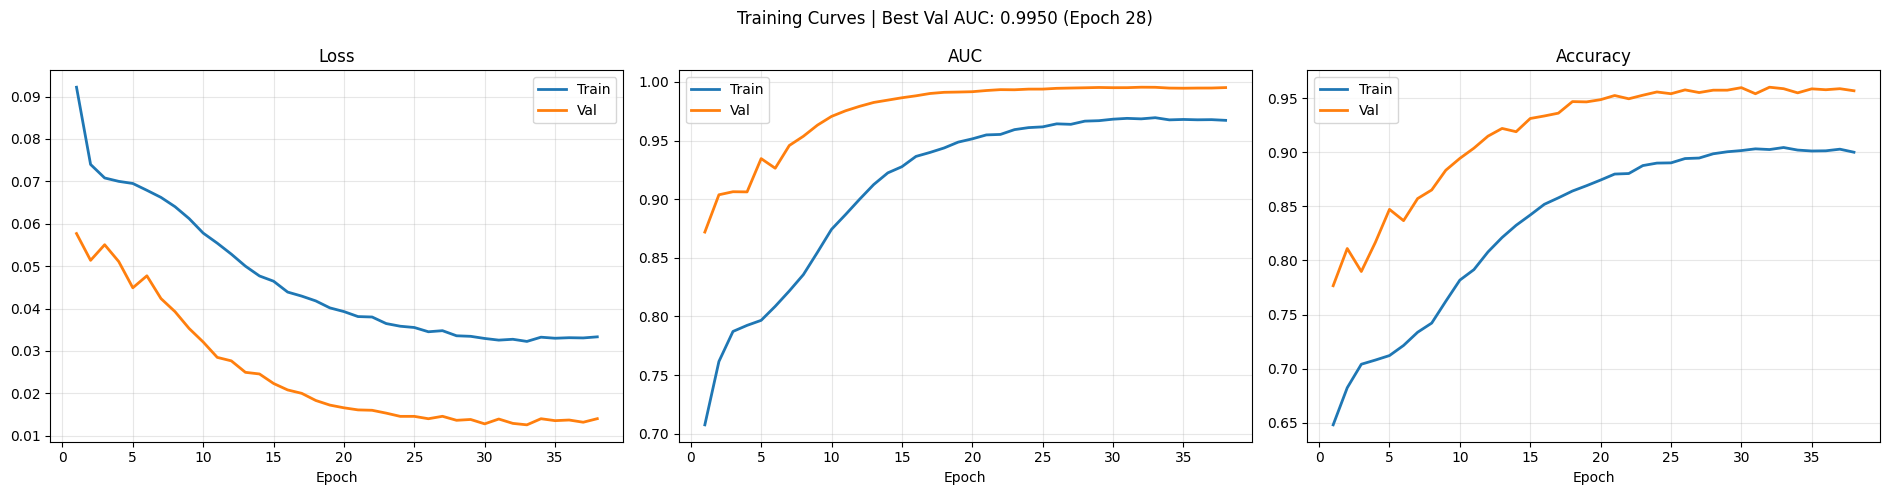


Running test set evaluation...


Test: 100%|███████████████████████████████████| 457/457 [05:37<00:00,  1.35it/s]


Test AUC: 0.9947
Optimal threshold: 0.46 (F1=0.9618)

Classification Report:
              precision    recall  f1-score   support

        REAL       0.96      0.96      0.96      3638
        FAKE       0.96      0.96      0.96      3670

    accuracy                           0.96      7308
   macro avg       0.96      0.96      0.96      7308
weighted avg       0.96      0.96      0.96      7308



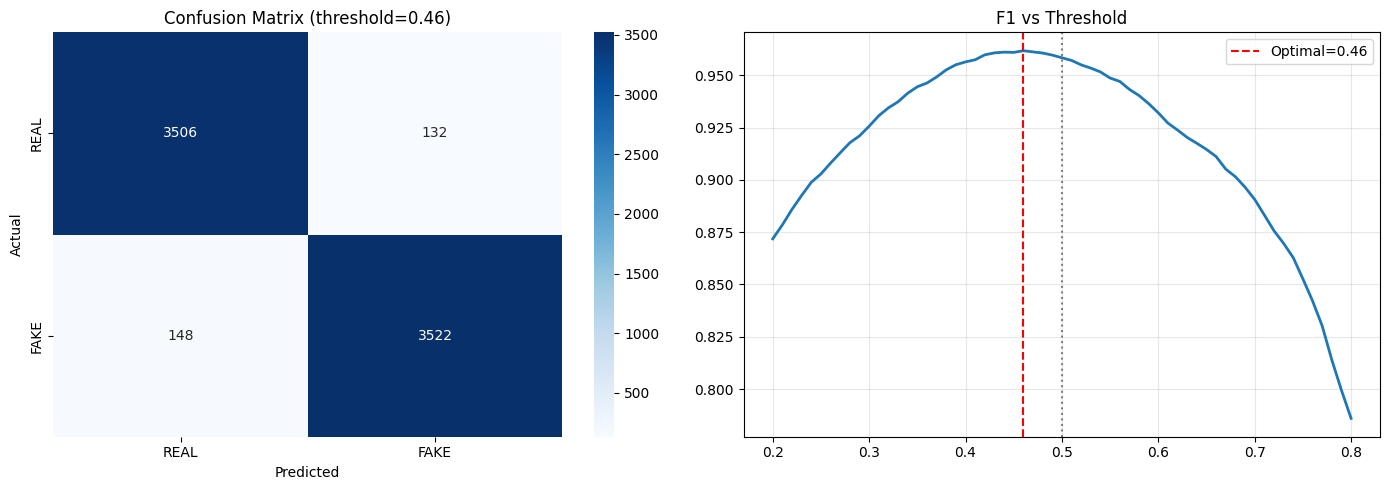

Threshold saved to checkpoint: 0.46


In [11]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score
from tqdm import tqdm

# ----------------------------
# CONFIG
# ----------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

best_path = r"D:\deepfake_project\models\checkpoints\best_model_v3.pth"
history_path = r"D:\deepfake_project\logs\history_v3.json"

# ----------------------------
# LOAD HISTORY
# ----------------------------
with open(history_path, 'r') as f:
    history = json.load(f)

print("Loaded history keys:", history.keys())

# ----------------------------
# LOAD MODEL
# ----------------------------
ckpt = torch.load(best_path, map_location=device)
print("Checkpoint keys:", ckpt.keys())

model.load_state_dict(ckpt['model_state'])
model.to(device)
model.eval()

epoch = ckpt.get('epoch', 'Unknown')
val_auc = ckpt.get('val_auc', ckpt.get('best_val_auc', 0.0))

print(f'Loaded best model — epoch {epoch}  Val AUC={val_auc:.4f}')

# ----------------------------
# PLOT TRAINING CURVES
# ----------------------------
ep_all = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle(f'Training Curves | Best Val AUC: {val_auc:.4f} (Epoch {epoch})')

for ax, metric, title in [
    (axes[0], 'loss', 'Loss'),
    (axes[1], 'auc', 'AUC'),
    (axes[2], 'acc', 'Accuracy')
]:
    ax.plot(ep_all, history[f'train_{metric}'], label='Train', linewidth=2)
    ax.plot(ep_all, history[f'val_{metric}'], label='Val', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# TEST EVALUATION
# ----------------------------
print('\nRunning test set evaluation...')
all_probs, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Test', ncols=80):
        imgs = imgs.to(device)

        with torch.amp.autocast('cuda', enabled=True):
            probs = torch.sigmoid(model(imgs)).cpu().numpy()

        all_probs.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().astype(int))

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# ----------------------------
# METRICS
# ----------------------------
test_auc = roc_auc_score(all_labels, all_probs)
print(f'Test AUC: {test_auc:.4f}')

# ----------------------------
# OPTIMAL THRESHOLD
# ----------------------------
thresholds = np.arange(0.2, 0.8, 0.01)
f1_scores = [f1_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]

OPTIMAL_THRESHOLD = thresholds[np.argmax(f1_scores)]
print(f'Optimal threshold: {OPTIMAL_THRESHOLD:.2f} (F1={max(f1_scores):.4f})')

# ----------------------------
# FINAL PREDICTIONS
# ----------------------------
y_pred = (all_probs >= OPTIMAL_THRESHOLD).astype(int)

print('\nClassification Report:')
print(classification_report(all_labels, y_pred, target_names=['REAL', 'FAKE']))

# ----------------------------
# CONFUSION MATRIX + F1 CURVE
# ----------------------------
cm = confusion_matrix(all_labels, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix (threshold={OPTIMAL_THRESHOLD:.2f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].plot(thresholds, f1_scores, linewidth=2)
axes[1].axvline(x=OPTIMAL_THRESHOLD, color='red', linestyle='--',
                label=f'Optimal={OPTIMAL_THRESHOLD:.2f}')
axes[1].axvline(x=0.5, color='gray', linestyle=':')
axes[1].set_title('F1 vs Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# SAVE THRESHOLD
# ----------------------------
ckpt['optimal_threshold'] = float(OPTIMAL_THRESHOLD)
torch.save(ckpt, best_path)

print(f'Threshold saved to checkpoint: {OPTIMAL_THRESHOLD:.2f}')

In [12]:
# # TRAINING CURVES + TEST EVALUATION

# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from sklearn.metrics import confusion_matrix, classification_report, f1_score
# import seaborn as sns

# # Load best model
# ckpt = torch.load(best_path, map_location=device)
# model.load_state_dict(ckpt['model_state'])
# model.eval()
# print(f'Loaded best model — epoch {ckpt["epoch"]}  Val AUC={ckpt["val_auc"]:.4f}')

# # Training curves
# ep_all = list(range(1, len(history['train_loss']) + 1))
# fig, axes = plt.subplots(1, 3, figsize=(19, 5))
# fig.suptitle(f'EfficientNet-B4 v3 @ 380px  |  Best Val AUC: {best_val_auc:.4f} at Ep {best_epoch}')

# p1p = mpatches.Patch(color='#3266ad', label='Phase 1')
# p2p = mpatches.Patch(color='#2ea86e', label='Phase 2')

# for ax, m, title in [(axes[0],'loss','Loss'),(axes[1],'auc','AUC'),(axes[2],'acc','Accuracy')]:
#     ax.plot(ep_all, history[f'train_{m}'], color='#3266ad', linewidth=2, label='Train')
#     ax.plot(ep_all, history[f'val_{m}'],   color='#e05c3a', linewidth=2, label='Val')
#     ax.axvspan(1, P1_EPOCHS+0.5, alpha=0.08, color='#3266ad')
#     ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
#     ax.set_title(title); ax.set_xlabel('Epoch')
#     ax.legend(handles=[p1p, p2p], fontsize=8); ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig(os.path.join(TRAIN_CONFIG['log_dir'], 'curves_v3.png'), dpi=120)
# plt.show()

# # Test evaluation
# print('\nRunning test set evaluation...')
# all_probs, all_labels = [], []
# with torch.no_grad():
#     for imgs, labels in tqdm(test_loader, desc='Test', ncols=80):
#         imgs = imgs.to(device, non_blocking=True)
#         with torch.amp.autocast('cuda', enabled=TRAIN_CONFIG['use_amp']):
#             probs = torch.sigmoid(model(imgs)).cpu().numpy()
#         all_probs.extend(probs.tolist())
#         all_labels.extend((labels > 0.5).int().numpy().tolist())
#         del imgs

# all_probs  = np.array(all_probs)
# all_labels = np.array(all_labels)

# test_auc = roc_auc_score(all_labels, all_probs)
# print(f'Test AUC: {test_auc:.4f}')

# thresholds  = np.arange(0.2, 0.8, 0.01)
# f1_scores   = [f1_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]
# OPTIMAL_THRESHOLD = float(thresholds[np.argmax(f1_scores)])
# print(f'Optimal threshold: {OPTIMAL_THRESHOLD:.2f}  (F1={max(f1_scores):.4f})')

# y_pred = (all_probs >= OPTIMAL_THRESHOLD).astype(int)
# print('\nClassification Report:')
# print(classification_report(all_labels, y_pred, target_names=['REAL', 'FAKE']))

# cm = confusion_matrix(all_labels, y_pred)
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'], ax=axes[0])
# axes[0].set_title(f'Confusion Matrix (threshold={OPTIMAL_THRESHOLD:.2f})')
# axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
# axes[1].plot(thresholds, f1_scores, color='#3266ad', linewidth=2)
# axes[1].axvline(x=OPTIMAL_THRESHOLD, color='red', linestyle='--',
#                 label=f'Optimal={OPTIMAL_THRESHOLD:.2f}')
# axes[1].axvline(x=0.5, color='gray', linestyle=':', label='Default=0.50')
# axes[1].set_title('F1 vs Threshold'); axes[1].legend(); axes[1].grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig(os.path.join(TRAIN_CONFIG['log_dir'], 'test_eval_v3.png'), dpi=120)
# plt.show()

# ckpt['optimal_threshold'] = OPTIMAL_THRESHOLD
# torch.save(ckpt, best_path)
# print(f'Threshold {OPTIMAL_THRESHOLD:.2f} saved with checkpoint')

In [13]:
# # CELL 9 — INFERENCE + WEB APP EXPORT

# import cv2
# import urllib.request
# from PIL import Image
# import torchvision.transforms as transforms

# # Face detector download (one-time)
# DETECTOR_DIR  = 'D:/deepfake_project/face_detector'
# os.makedirs(DETECTOR_DIR, exist_ok=True)
# proto_path   = os.path.join(DETECTOR_DIR, 'deploy.prototxt')
# weights_path = os.path.join(DETECTOR_DIR, 'res10_300x300_ssd_iter_140000.caffemodel')

# if not os.path.exists(proto_path):
#     urllib.request.urlretrieve(
#         'https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt',
#         proto_path)
# if not os.path.exists(weights_path):
#     print('Downloading face detector (~10 MB)...')
#     urllib.request.urlretrieve(
#         'https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel',
#         weights_path)

# face_net = cv2.dnn.readNet(weights_path, proto_path)
# print('Face detector loaded')

# inference_transform = transforms.Compose([
#     transforms.Resize((TRAIN_CONFIG['image_size'], TRAIN_CONFIG['image_size'])),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=TRAIN_CONFIG['mean'], std=TRAIN_CONFIG['std']),
# ])


# def detect_and_crop_face(image_path, margin=0.2):
#     img_bgr = cv2.imread(image_path)
#     if img_bgr is None:
#         return Image.open(image_path).convert('RGB'), False
#     h, w = img_bgr.shape[:2]
#     blob = cv2.dnn.blobFromImage(cv2.resize(img_bgr, (300, 300)),
#                                   1.0, (300, 300), (104.0, 177.0, 123.0))
#     face_net.setInput(blob)
#     det = face_net.forward()
#     best_conf, best_box = 0.0, None
#     for i in range(det.shape[2]):
#         c = det[0, 0, i, 2]
#         if c > 0.5 and c > best_conf:
#             best_conf = c
#             x1 = int(det[0,0,i,3]*w); y1 = int(det[0,0,i,4]*h)
#             x2 = int(det[0,0,i,5]*w); y2 = int(det[0,0,i,6]*h)
#             best_box = (x1, y1, x2, y2)
#     if best_box is None:
#         img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
#         pil = Image.fromarray(img_rgb)
#         s = min(w, h)
#         return pil.crop(((w-s)//2, (h-s)//2, (w+s)//2, (h+s)//2)), False
#     x1, y1, x2, y2 = best_box
#     bw, bh = x2-x1, y2-y1
#     x1 = max(0, int(x1-margin*bw)); y1 = max(0, int(y1-margin*bh))
#     x2 = min(w, int(x2+margin*bw)); y2 = min(h, int(y2+margin*bh))
#     return Image.fromarray(cv2.cvtColor(img_bgr[y1:y2,x1:x2], cv2.COLOR_BGR2RGB)), True


# def predict_image(image_path, threshold=None):
#     if threshold is None: threshold = OPTIMAL_THRESHOLD
#     face_img, face_found = detect_and_crop_face(image_path)
#     tensor = inference_transform(face_img).unsqueeze(0).to(device)
#     model.eval()
#     with torch.no_grad():
#         with torch.amp.autocast('cuda', enabled=TRAIN_CONFIG['use_amp']):
#             prob = torch.sigmoid(model(tensor)).item()
#     del tensor
#     label = 'FAKE' if prob >= threshold else 'REAL'
#     conf  = prob if prob >= threshold else 1.0 - prob
#     return {'label': label, 'confidence': round(conf*100, 2),
#             'fake_prob': round(prob*100, 2), 'real_prob': round((1-prob)*100, 2),
#             'face_detected': face_found, 'threshold': round(threshold, 2)}


# print('predict_image() ready')
# print(f'  Threshold : {OPTIMAL_THRESHOLD:.2f} (calibrated on test set)')

# # ── ONNX Export for Web Application 

# print('\nExporting to ONNX for web deployment...')
# model.eval()
# model_cpu = model.cpu()

# dummy_input = torch.randn(1, 3, 380, 380)
# onnx_path   = os.path.join(TRAIN_CONFIG['checkpoint_dir'], 'deepfake_model_v3.onnx')

# torch.onnx.export(
#     model_cpu,
#     dummy_input,
#     onnx_path,
#     export_params   = True,
#     opset_version   = 17,
#     do_constant_folding = True,
#     input_names     = ['image'],
#     output_names    = ['logit'],
#     dynamic_axes    = {'image': {0: 'batch_size'}, 'logit': {0: 'batch_size'}}
# )

# model = model_cpu.to(device)  # move back to GPU
# onnx_size = os.path.getsize(onnx_path) / 1e6
# print(f'  ONNX saved: {onnx_path}')
# print(f'  ONNX size : {onnx_size:.1f} MB')
# print(f'  Use onnxruntime in your web app backend')
# print(f'  pip install onnxruntime')
# print(f'  import onnxruntime as ort')
# print(f'  sess = ort.InferenceSession("{onnx_path}")')
# print(f'  logit = sess.run(["logit"], {{"image": img_array}})[0]')
# print(f'  prob = 1 / (1 + exp(-logit))  # sigmoid')

In [14]:
import os
import cv2
import torch
import urllib.request
import numpy as np
from PIL import Image
import torchvision.transforms as transforms

# ----------------------------
# CONFIG
# ----------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

DETECTOR_DIR = 'D:/deepfake_project/face_detector'
os.makedirs(DETECTOR_DIR, exist_ok=True)

proto_path   = os.path.join(DETECTOR_DIR, 'deploy.prototxt')
weights_path = os.path.join(DETECTOR_DIR, 'res10_300x300_ssd_iter_140000.caffemodel')

# ----------------------------
# DOWNLOAD FACE DETECTOR
# ----------------------------
if not os.path.exists(proto_path):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt',
        proto_path)

if not os.path.exists(weights_path):
    print('Downloading face detector (~10 MB)...')
    urllib.request.urlretrieve(
        'https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel',
        weights_path)

# Load once
face_net = cv2.dnn.readNetFromCaffe(proto_path, weights_path)
print('Face detector loaded')

# ----------------------------
# TRANSFORM
# ----------------------------
inference_transform = transforms.Compose([
    transforms.Resize((TRAIN_CONFIG['image_size'], TRAIN_CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_CONFIG['mean'], std=TRAIN_CONFIG['std']),
])

# ----------------------------
# FACE DETECTION (Optimized)
# ----------------------------
def detect_and_crop_face(image_path, margin=0.2):
    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        return Image.open(image_path).convert('RGB'), False

    h, w = img_bgr.shape[:2]

    blob = cv2.dnn.blobFromImage(img_bgr, 1.0, (300, 300),
                                 (104.0, 177.0, 123.0), swapRB=False)

    face_net.setInput(blob)
    detections = face_net.forward()

    best_conf = 0
    best_box = None

    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf > 0.5 and conf > best_conf:
            best_conf = conf
            x1 = int(detections[0,0,i,3] * w)
            y1 = int(detections[0,0,i,4] * h)
            x2 = int(detections[0,0,i,5] * w)
            y2 = int(detections[0,0,i,6] * h)
            best_box = (x1, y1, x2, y2)

    if best_box is None:
        # fallback center crop
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(img_rgb)
        s = min(w, h)
        return pil.crop(((w-s)//2, (h-s)//2, (w+s)//2, (h+s)//2)), False

    x1, y1, x2, y2 = best_box
    bw, bh = x2 - x1, y2 - y1

    x1 = max(0, int(x1 - margin * bw))
    y1 = max(0, int(y1 - margin * bh))
    x2 = min(w, int(x2 + margin * bw))
    y2 = min(h, int(y2 + margin * bh))

    face = img_bgr[y1:y2, x1:x2]
    face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

    return Image.fromarray(face_rgb), True

# ----------------------------
# PREDICTION (Optimized)
# ----------------------------
def predict_image(image_path, threshold=None):
    threshold = threshold if threshold is not None else OPTIMAL_THRESHOLD

    face_img, face_found = detect_and_crop_face(image_path)
    tensor = inference_transform(face_img).unsqueeze(0).to(device)

    with torch.no_grad():
        if device == 'cuda':
            with torch.amp.autocast('cuda'):
                prob = torch.sigmoid(model(tensor)).item()
        else:
            prob = torch.sigmoid(model(tensor)).item()

    label = 'FAKE' if prob >= threshold else 'REAL'
    confidence = prob if prob >= threshold else 1 - prob

    return {
        'label': label,
        'confidence': round(confidence * 100, 2),
        'fake_prob': round(prob * 100, 2),
        'real_prob': round((1 - prob) * 100, 2),
        'face_detected': face_found,
        'threshold': round(threshold, 2)
    }

print('predict_image() ready')

# ----------------------------
# ONNX EXPORT (Optimized)
# ----------------------------
print('\nExporting to ONNX...')

model.eval()
model_cpu = model.to('cpu')

dummy_input = torch.randn(1, 3, TRAIN_CONFIG['image_size'], TRAIN_CONFIG['image_size'])

onnx_path = os.path.join(TRAIN_CONFIG['checkpoint_dir'], 'deepfake_model_v3.onnx')

torch.onnx.export(
    model_cpu,
    dummy_input,
    onnx_path,
    opset_version=17,
    do_constant_folding=True,
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={
        'image': {0: 'batch_size'},
        'logits': {0: 'batch_size'}
    }
)

# Move back to device
model.to(device)

print(f'ONNX saved at: {onnx_path}')
print(f'Size: {os.path.getsize(onnx_path)/1e6:.2f} MB')

# ----------------------------
# ONNX USAGE GUIDE
# ----------------------------
print("\nONNX Runtime Example:")
print("""
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession("deepfake_model_v3.onnx")

outputs = sess.run(
    ["logits"],
    {"image": img_array.astype(np.float32)}
)

logit = outputs[0]
prob = 1 / (1 + np.exp(-logit))
""")

Face detector loaded
predict_image() ready

Exporting to ONNX...
ONNX saved at: D:/deepfake_project/models/checkpoints\deepfake_model_v3.onnx
Size: 73.76 MB

ONNX Runtime Example:

import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession("deepfake_model_v3.onnx")

outputs = sess.run(
    ["logits"],
    {"image": img_array.astype(np.float32)}
)

logit = outputs[0]
prob = 1 / (1 + np.exp(-logit))



In [15]:
# TEST YOUR REAL-WORLD PHOTOS

test_images = [
    ('D:/IMAGEDEEPFAKE/images/Pi7_Passport_Photo-removebg-preview.png', 'REAL expected'),
    ('D:/IMAGEDEEPFAKE/images/person.jpg',                               'REAL expected'),
    ('D:/IMAGEDEEPFAKE/images/WhatsApp Image 2026-02-16 at 4.29.52 AM.jpeg', 'REAL expected'),
    ('D:/IMAGEDEEPFAKE/images/WhatsApp Image 2026-02-16 at 2.28.40 PM.jpeg', 'check'),
    ('D:/Downloads/OIP..jpg',                                            'REAL expected'),
]

print('=' * 70)
print('REAL-WORLD IMAGE TEST')
print('=' * 70)

for path, note in test_images:
    if not os.path.exists(path):
        print(f'  SKIP: {os.path.basename(path)}')
        continue
    r = predict_image(path)
    tag = 'face-ok' if r['face_detected'] else 'no-face'
    print(f'  {os.path.basename(path)[:38]:<38}  '
          f'{r["label"]:4s} {r["confidence"]:.1f}%  '
          f'[fake={r["fake_prob"]:.1f}%] [{tag}]  <- {note}')

print('\nDone')

REAL-WORLD IMAGE TEST
  Pi7_Passport_Photo-removebg-preview.pn  REAL 73.1%  [fake=26.9%] [face-ok]  <- REAL expected
  person.jpg                              REAL 95.8%  [fake=4.2%] [face-ok]  <- REAL expected
  WhatsApp Image 2026-02-16 at 4.29.52 A  REAL 98.2%  [fake=1.8%] [face-ok]  <- REAL expected
  WhatsApp Image 2026-02-16 at 2.28.40 P  REAL 77.9%  [fake=22.1%] [face-ok]  <- check
  OIP..jpg                                REAL 63.3%  [fake=36.7%] [no-face]  <- REAL expected

Done


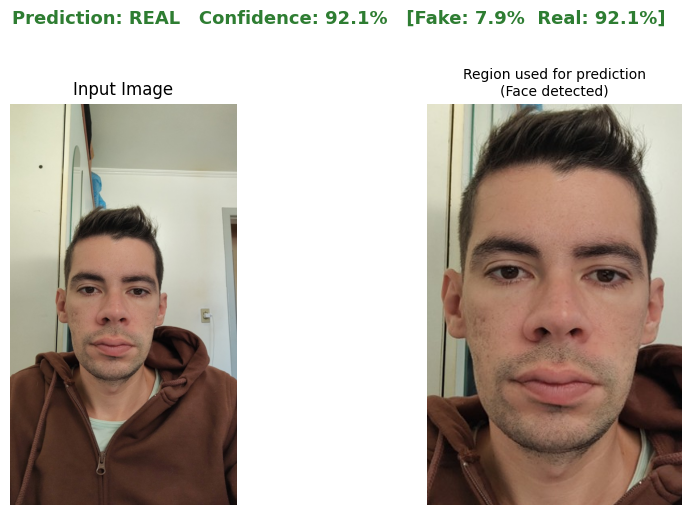


  File       : real_1 (1).jpg
  Format     : .JPG
  Result     : REAL
  Confidence : 92.12%
  Fake prob  : 7.88%
  Real prob  : 92.12%
  Face found : True
  Threshold  : 0.46



In [16]:
# Image Testing
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2, numpy as np, torch

IMAGE_PATH = r"C:\Users\abida\DEEPFAKE_DETECTION_SYSTEM\image dataset\Deep-vs-Real\real\real_1 (1).jpg"   # supports jpg, jpeg, png, bmp, webp

def test_any_image(image_path, show_plot=True):
    """
    Test any image file for deepfake detection.
    Accepts: jpg, jpeg, png, bmp, webp, tiff
    Shows: original image + prediction result + face crop used
    """
    import os
    if not os.path.exists(image_path):
        print(f"File not found: {image_path}")
        return None

    # Step 1: Load original for display
    orig_bgr = cv2.imread(image_path)
    if orig_bgr is None:
        # Try PIL for formats OpenCV struggles with (some PNGs)
        orig_pil = Image.open(image_path).convert('RGB')
        orig_bgr = cv2.cvtColor(np.array(orig_pil), cv2.COLOR_RGB2BGR)
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)

    # Step 2: Run face detection + prediction
    result = predict_image(image_path)

    # Step 3: Get the face crop for display
    face_img, face_found = detect_and_crop_face(image_path)
    face_arr = np.array(face_img)

    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Left: original image
        axes[0].imshow(orig_rgb)
        axes[0].set_title('Input Image', fontsize=12)
        axes[0].axis('off')

        # Right: face crop used for prediction
        axes[1].imshow(face_arr)
        face_tag = "Face detected" if face_found else "No face — center crop used"
        axes[1].set_title(f'Region used for prediction\n({face_tag})', fontsize=10)
        axes[1].axis('off')

        # Result banner
        color = '#d32f2f' if result['label'] == 'FAKE' else '#2e7d32'
        fig.patch.set_facecolor('white')
        plt.suptitle(
            f"Prediction: {result['label']}   "
            f"Confidence: {result['confidence']:.1f}%   "
            f"[Fake: {result['fake_prob']:.1f}%  Real: {result['real_prob']:.1f}%]",
            fontsize=13, fontweight='bold', color=color, y=1.02
        )
        plt.tight_layout()
        plt.show()

    # Print result
    print(f"\n{'='*50}")
    print(f"  File       : {os.path.basename(image_path)}")
    print(f"  Format     : {os.path.splitext(image_path)[1].upper()}")
    print(f"  Result     : {result['label']}")
    print(f"  Confidence : {result['confidence']:.2f}%")
    print(f"  Fake prob  : {result['fake_prob']:.2f}%")
    print(f"  Real prob  : {result['real_prob']:.2f}%")
    print(f"  Face found : {result['face_detected']}")
    print(f"  Threshold  : {result['threshold']}")
    print(f"{'='*50}\n")

    return result


# Run it
result = test_any_image(IMAGE_PATH)

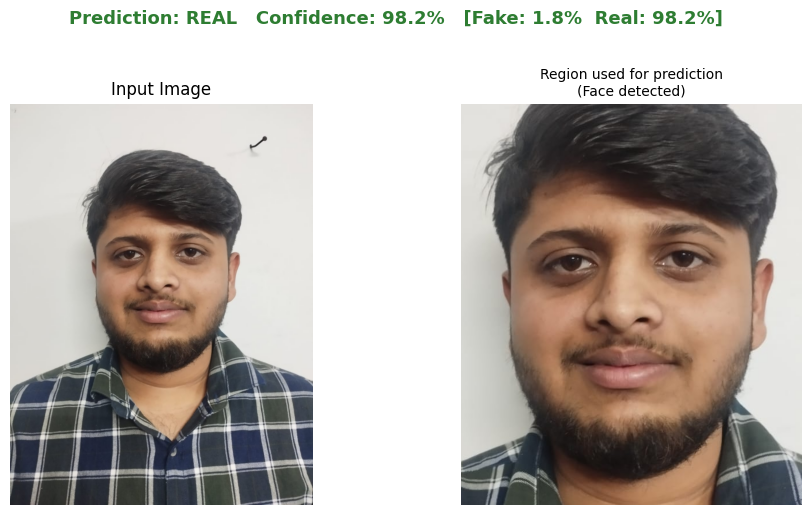


  File       : WhatsApp Image 2026-02-16 at 4.29.52 AM.jpeg
  Format     : .JPEG
  Result     : REAL
  Confidence : 98.22%
  Fake prob  : 1.78%
  Real prob  : 98.22%
  Face found : True
  Threshold  : 0.46



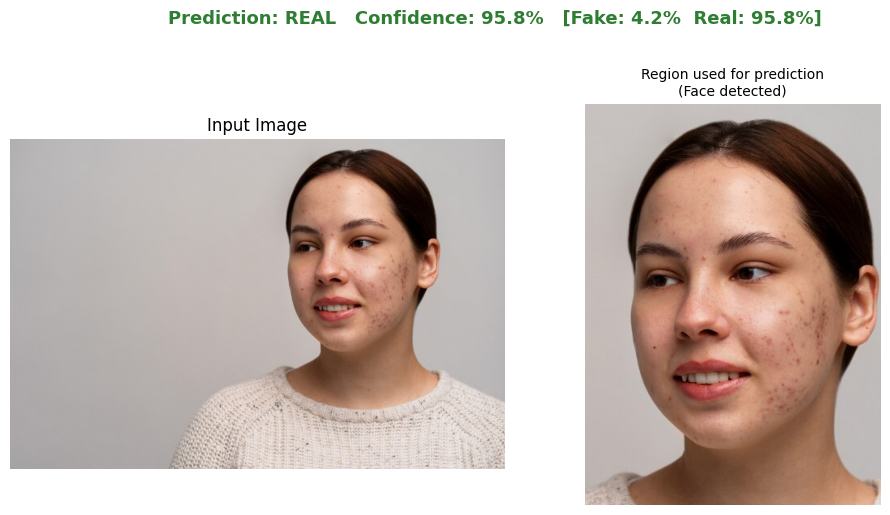


  File       : person.jpg
  Format     : .JPG
  Result     : REAL
  Confidence : 95.84%
  Fake prob  : 4.16%
  Real prob  : 95.84%
  Face found : True
  Threshold  : 0.46



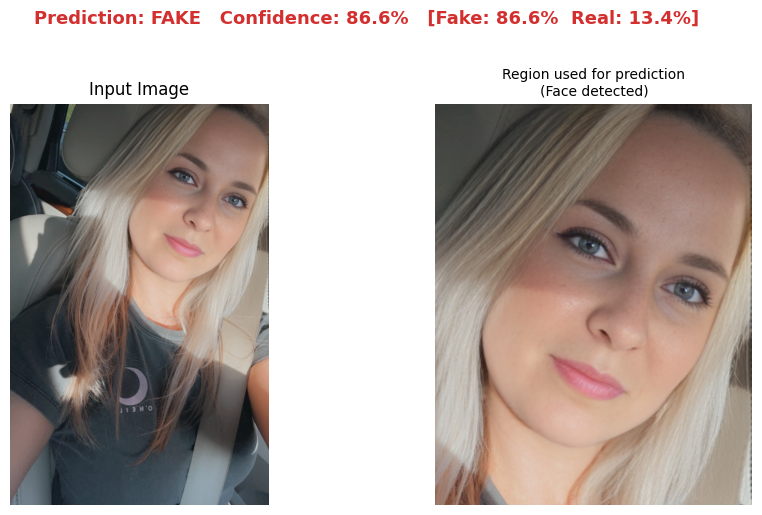


  File       : fake_1 (5530).jpg
  Format     : .JPG
  Result     : FAKE
  Confidence : 86.57%
  Fake prob  : 86.57%
  Real prob  : 13.43%
  Face found : True
  Threshold  : 0.46



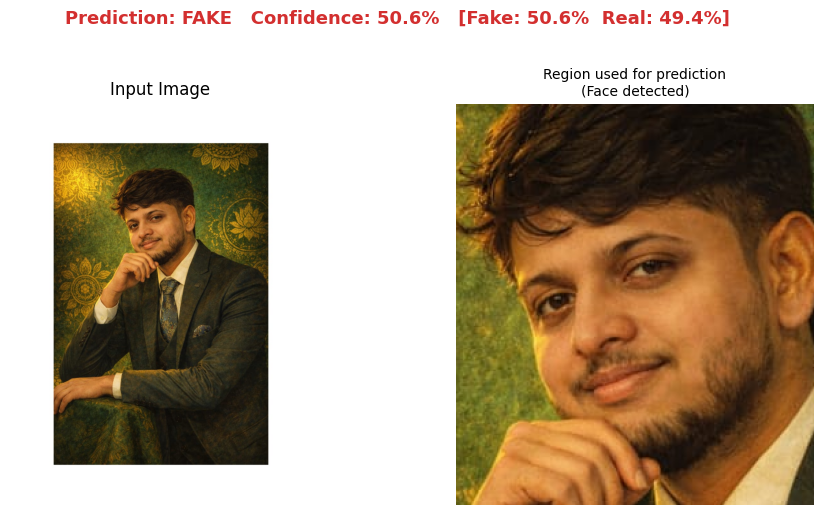


  File       : WhatsApp Image 2026-02-16 at 4.29.58 AM.jpeg
  Format     : .JPEG
  Result     : FAKE
  Confidence : 50.63%
  Fake prob  : 50.63%
  Real prob  : 49.37%
  Face found : True
  Threshold  : 0.46



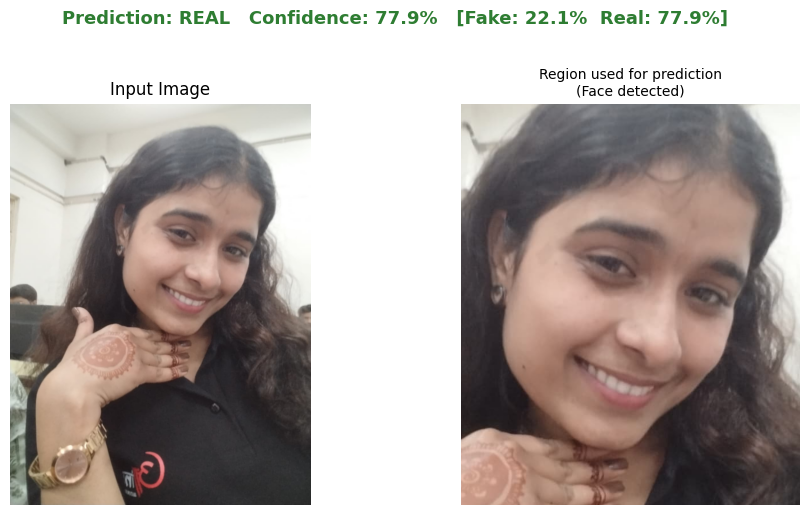


  File       : WhatsApp Image 2026-02-16 at 2.28.40 PM.jpeg
  Format     : .JPEG
  Result     : REAL
  Confidence : 77.87%
  Fake prob  : 22.13%
  Real prob  : 77.87%
  Face found : True
  Threshold  : 0.46



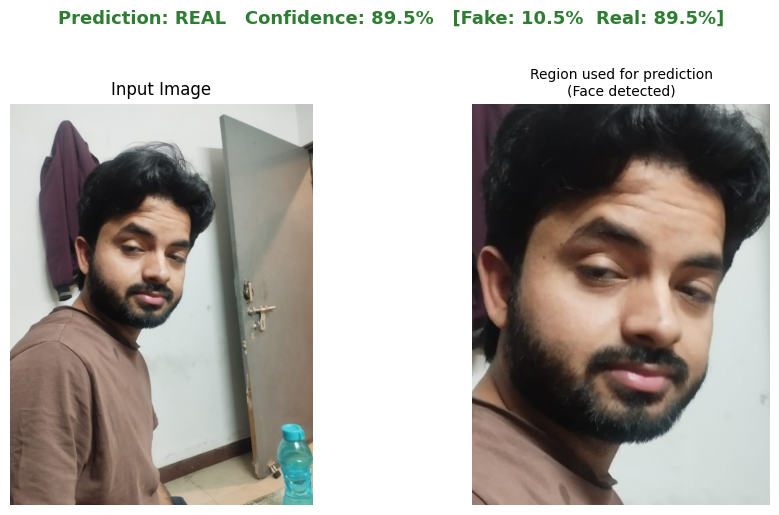


  File       : WhatsApp Image 2026-02-16 at 11.50.09 PM.jpeg
  Format     : .JPEG
  Result     : REAL
  Confidence : 89.53%
  Fake prob  : 10.47%
  Real prob  : 89.53%
  Face found : True
  Threshold  : 0.46



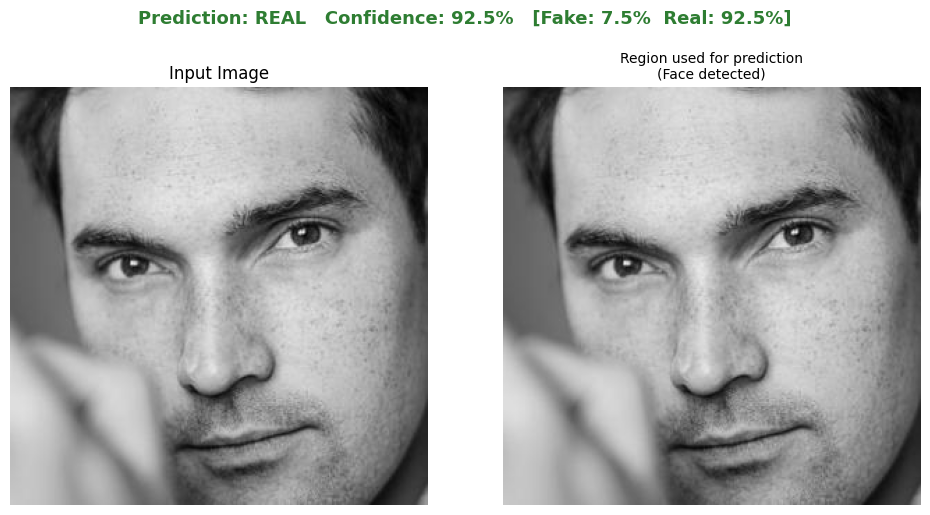


  File       : real_6.jpg
  Format     : .JPG
  Result     : REAL
  Confidence : 92.48%
  Fake prob  : 7.52%
  Real prob  : 92.48%
  Face found : True
  Threshold  : 0.46



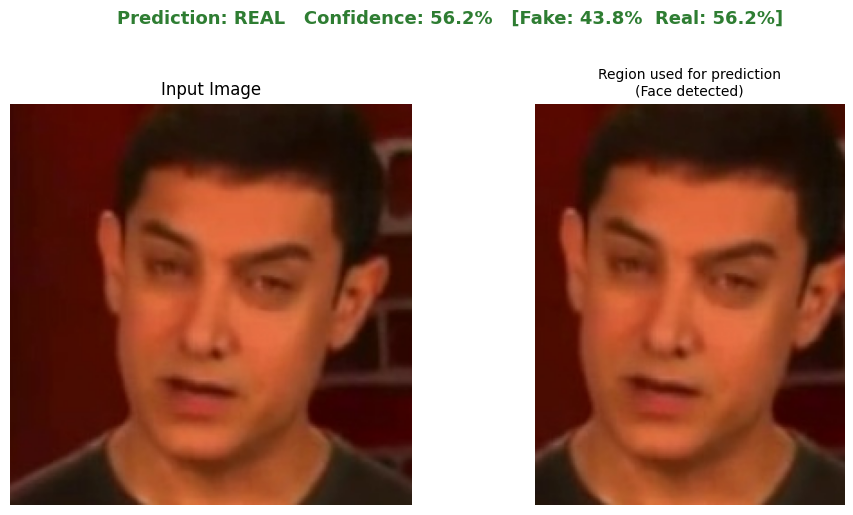


  File       : 0000019.jpg
  Format     : .JPG
  Result     : REAL
  Confidence : 56.20%
  Fake prob  : 43.80%
  Real prob  : 56.20%
  Face found : True
  Threshold  : 0.46



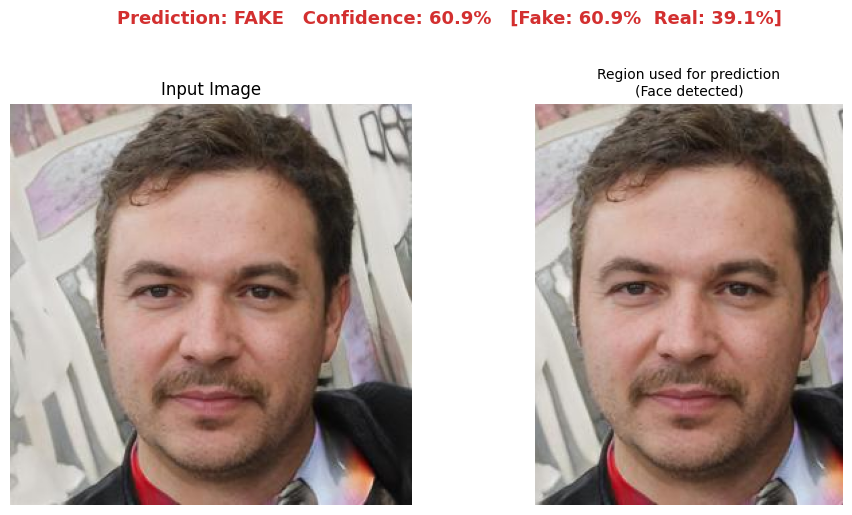


  File       : fake_93.jpg
  Format     : .JPG
  Result     : FAKE
  Confidence : 60.89%
  Fake prob  : 60.89%
  Real prob  : 39.11%
  Face found : True
  Threshold  : 0.46



In [17]:
# Test a list of images
test_batch = [
    r"D:/IMAGEDEEPFAKE/images/WhatsApp Image 2026-02-16 at 4.29.52 AM.jpeg",
    r"D:/IMAGEDEEPFAKE/images/person.jpg",
    r"C:\Users\abida\DEEPFAKE_DETECTION_SYSTEM\image dataset\Deep-vs-Real\fake\fake_1 (5530).jpg",
    r"D:\IMAGEDEEPFAKE\images\WhatsApp Image 2026-02-16 at 4.29.58 AM.jpeg",
    r"D:\IMAGEDEEPFAKE\images\WhatsApp Image 2026-02-16 at 2.28.40 PM.jpeg",
    r"D:\IMAGEDEEPFAKE\images\WhatsApp Image 2026-02-16 at 11.50.09 PM.jpeg",
    r"D:\IMAGEDEEPFAKE\images\real_6.jpg",
    r"D:\IMAGEDEEPFAKE\images\0000019.jpg",
    r"C:\Users\abida\DEEPFAKE_DETECTION_SYSTEM\image dataset\real-vs-hardfakes\fake\fake_93.jpg"
]

for path in test_batch:
    test_any_image(path, show_plot=True)